# DriveInsight

## About

DriveInsight is a large-scale, CCTV-based traffic dataset that bridges the gap between real-world traffic observations and simulation-ready scenarios. Scenarios are extracted from 24/7 CCTV camera feeds at urban intersections across more than 20 locations in multiple countries, then converted into standardized OpenSCENARIO (.xosc) format. Each scenario ships with a corresponding OpenDRIVE (.xodr) road network, weather metadata, and temporal annotations, making it directly compatible with simulation tools such as esmini, CARLA, and VTD.

The dataset covers a diverse range of traffic participants and is designed for trajectory forecasting, scenario-based ADAS validation, multi-agent interaction modelling, and long-tail behaviour analysis.

### How to Obtain the Dataset

The DriveInsight dataset is publicly available on GitHub. Clone the repository directly to get started:

```bash
git clone https://github.com/Drive1nsight/driveinsightD.git
cd driveinsightD
```

For extended intersections, additional scenario collections, and high-resolution CCTV source footage, submit a request via the project website at [https://driveinsight.io](https://driveinsight.io).

### How to Obtain the Map

Road network files in OpenDRIVE (.xodr) format are bundled with the dataset under each location folder:

```
driveinsightD/
└── database/
    └── <location_id>/
        ├── {id}_scenario.xosc          # OpenSCENARIO trajectory file
        ├── {id}_scenario_metadata.json # Scenario metadata
        ├── <location_id>.xodr          # OpenDRIVE road network
        └── <location_id>.osgb          # 3D environment model
```

No separate download is required — the map file for each location is located in the same folder as the scenario files.

### Citation

```latex
@article{zhdanov2025driveinsight,
  title={DriveInsight: CCTV-based dataset capturing real-world scenarios},
  author={Zhdanov, Pavlo and Yerumbayev, Sultan and Khan, Adil and Ram{\'i}rez Rivera, Ad{\'i}n},
  journal={IEEE Transactions on Circuits and Systems for Video Technology},
  year={2025},
  note={Under review}
}
```

## Data Analysis

> This part is independently conducted by Tactics2D.

### Trajectory Types in DriveInsight

- `Car`
- `Truck`
- `Bus`
- `Motorcycle`
- `Bicycle`
- `Pedestrian`

In [17]:
import io
import os
import sys
import warnings

# ---------------------------------------------------------------------------
# Dataset paths — update these to match your local installation
# ---------------------------------------------------------------------------
os.environ["DRIVEINSIGHTD_FOLDER"]    = "/root/autodl-tmp/driveinsightD/database/cz_zlin"
os.environ["DRIVEINSIGHTD_CZ_FOLDER"] = "/root/autodl-tmp/driveinsightD/database/cz_zlin"
os.environ["DRIVEINSIGHTD_JP_FOLDER"] = "/root/autodl-tmp/driveinsightD/database/jp_taito"
os.environ["DRIVEINSIGHTD_US_FOLDER"] = "/root/autodl-tmp/driveinsightD/database/us_coldwater"

warnings.filterwarnings("ignore")

import logging
logging.basicConfig(level=logging.ERROR,force=True)


# Required for off-screen rendering in notebook environments
os.environ.setdefault("SDL_VIDEODRIVER", "dummy")

sys.path.insert(0, "/root/autodl-tmp/tactics2d")

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from IPython.display import Image as IPImage, display

In [18]:
mpl.rcParams.update(
    {
        "figure.dpi": 300,
        "font.family": "DejaVu Sans Mono",
        "font.size": 6,
        "font.stretch": "semi-expanded",
        "animation.html": "jshtml",
        "animation.embed_limit": 5000,
        "axes.edgecolor": "black",
        "axes.linewidth": 0.8,
        "axes.facecolor": "white",
    }
)


def render_scenario_frame(scenario: dict, window_size=(800, 800)) -> IPImage:
    """Render the first active frame of a scenario and return an IPython Image.

    Args:
        scenario (dict): Output of DriveInsightDParser.parse().
        window_size (tuple): Width and height of the rendered frame in pixels.

    Returns:
        IPython.display.Image: Inline-displayable PNG image.
    """
    from tactics2d.sensor import TopDownCamera

    map_          = scenario["map"]
    participants  = scenario["participants"]

    # Collect all timestamps and pick the midpoint for a representative frame
    all_ts = set()
    for p in participants.values():
        frames = getattr(p.trajectory, "frames", None)
        if frames is not None:
            all_ts.update(frames)
    times = sorted(all_ts)
    t = times[len(times) // 2]  # midpoint frame

    # get_state raises KeyError when the timestamp is not in the trajectory,
    # so we wrap it in try/except instead of checking is not None.
    active = {}
    for pid, p in participants.items():
        try:
            state = p.trajectory.get_state(t)
            if state is not None:
                active[pid] = p
        except (KeyError, AttributeError):
            pass

    camera = TopDownCamera(1, map_, window_size=window_size, off_screen=True)
    camera.update(active, list(active.keys()), t)
    obs = camera.get_observation()

    img = Image.fromarray(obs).rotate(270)
    buf = io.BytesIO()
    img.save(buf, format="PNG")
    return IPImage(data=buf.getvalue(), width=600)

### Parse Trajectory

In [19]:
from tactics2d.dataset_parser import DriveInsightDParser

dataset_path = os.environ.get(
    "DRIVEINSIGHTD_FOLDER",
    "../../tactics2d/data/trajectory_sample/DriveInsightD/cz_zlin",
)
map_name = os.environ.get("DRIVEINSIGHTD_MAP", "cz_zlin.xodr")

dataset_parser = DriveInsightDParser()

participants, time_range = dataset_parser.parse_trajectory(
    file="106", folder=dataset_path
)

print(f"Number of participants : {len(participants)}")
print(f"Time range             : {time_range[0]} ms -> {time_range[1]} ms")

Number of participants : 11
Time range             : 0 ms -> 14750 ms


### Parse Map

In [20]:
from tactics2d.map.parser import XODRParser

map_parser = XODRParser()
map_ = map_parser.parse(file_path=os.path.join(dataset_path, map_name))

print(f"Number of lanes     : {len(map_.lanes)}")
print(f"Number of roadlines : {len(map_.roadlines)}")
print(f"Number of junctions : {len(map_.junctions)}")

Number of lanes     : 69
Number of roadlines : 92
Number of junctions : 1


### Load Full Scenario

In [21]:
scenario = dataset_parser.parse(
    scenario_id="106",
    folder=dataset_path,
    map_name=map_name,
)

print(f"Scenario ID   : {scenario['scenario_id']}")
print(f"Weather       : {scenario['metadata']['weather']}")
print(f"Precipitation : {scenario['metadata']['precipitation']}")
print(f"Recorded at   : {scenario['metadata']['time']}")
print(f"Road friction : {scenario['metadata']['friction']}")
print(f"Participants  : {len(scenario['participants'])}")
print(f"Time range    : {scenario['time_range'][0]} ms -> {scenario['time_range'][1]} ms")

Scenario ID   : 106
Weather       : free
Precipitation : dry
Recorded at   : 2020-03-20T12:00:00
Road friction : 1.0
Participants  : 11
Time range    : 0 ms -> 14750 ms


### Visualisation

The following figures show top-down renderings of three DriveInsightD locations parsed and visualised using Tactics2D. Each location uses a distinct OpenDRIVE road network, demonstrating the parser's ability to handle diverse intersection geometries across different countries.

Zlin, Czech Republic — scenario 106
  Participants : 11
  Lanes        : 69


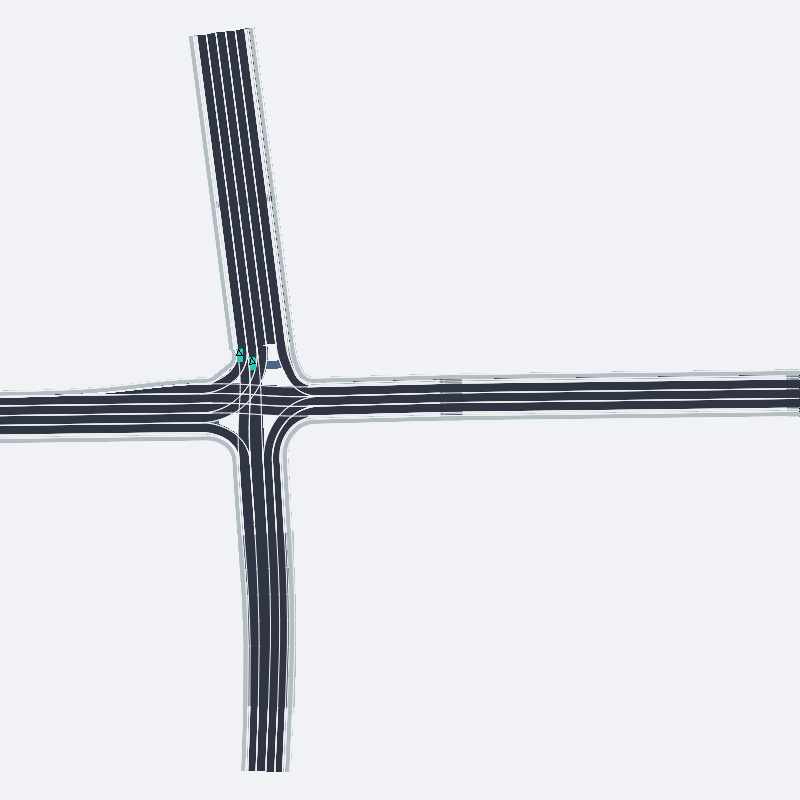

In [22]:
# ------------------------------------------------------------------
# Zlin, Czech Republic  —  scenario 106  (cz_zlin.xodr)
# ------------------------------------------------------------------
cz_folder = os.environ.get(
    "DRIVEINSIGHTD_CZ_FOLDER",
    "../../tactics2d/data/trajectory_sample/DriveInsightD/cz_zlin",
)

cz_scenario = dataset_parser.parse(
    scenario_id="106",
    folder=cz_folder,
    map_name="cz_zlin.xodr",
)

print("Zlin, Czech Republic — scenario 106")
print(f"  Participants : {len(cz_scenario['participants'])}")
print(f"  Lanes        : {len(cz_scenario['map'].lanes)}")
display(render_scenario_frame(cz_scenario))

Taito, Japan — scenario 6
  Participants : 13
  Lanes        : 79


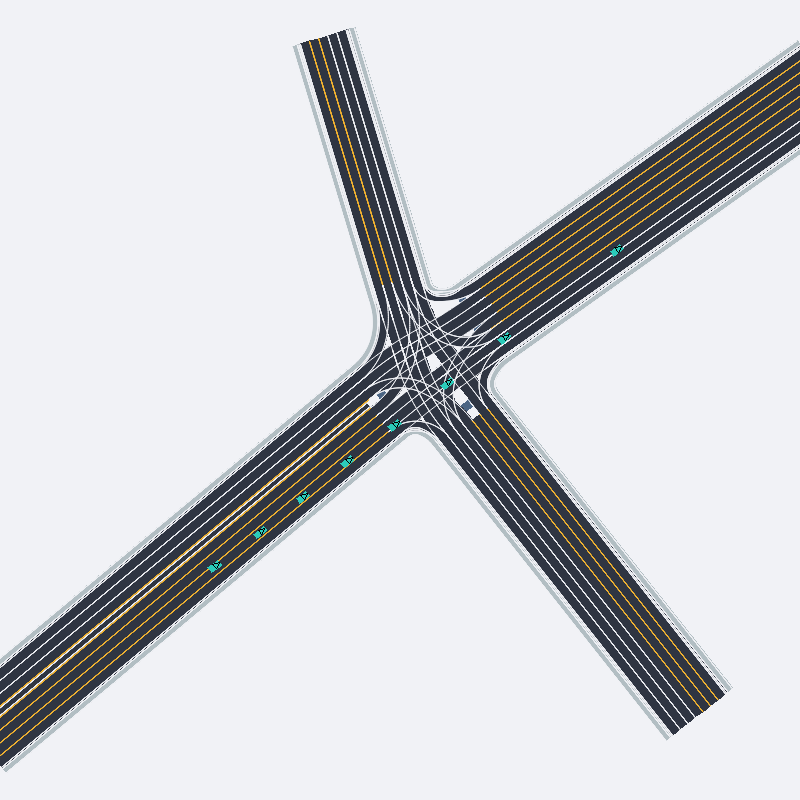

In [23]:
# ------------------------------------------------------------------
# Taito, Japan  —  scenario 6  (jp_taito.xodr)
# ------------------------------------------------------------------
jp_folder = os.environ.get(
    "DRIVEINSIGHTD_JP_FOLDER",
    "../../tactics2d/data/trajectory_sample/DriveInsightD/jp_taito",
)

jp_scenario = dataset_parser.parse(
    scenario_id="6",
    folder=jp_folder,
    map_name="jp_taito.xodr",
)

print("Taito, Japan — scenario 6")
print(f"  Participants : {len(jp_scenario['participants'])}")
print(f"  Lanes        : {len(jp_scenario['map'].lanes)}")
display(render_scenario_frame(jp_scenario))

Coldwater, United States — scenario 55
  Participants : 16
  Lanes        : 234


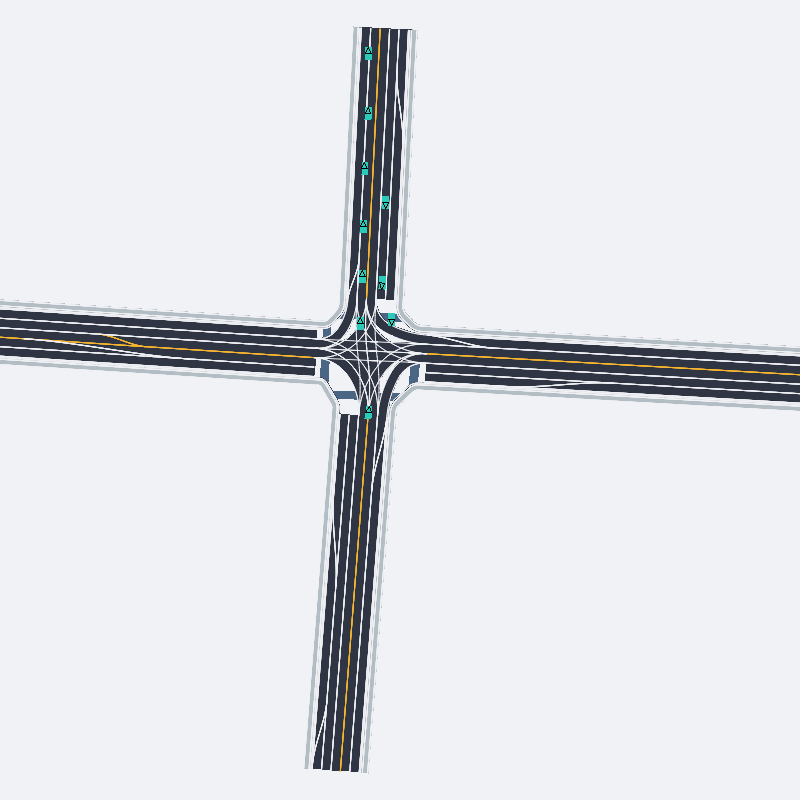

In [24]:
# ------------------------------------------------------------------
# Coldwater, United States  —  scenario 55  (usa_coldwater.xodr)
# ------------------------------------------------------------------
us_folder = os.environ.get(
    "DRIVEINSIGHTD_US_FOLDER",
    "../../tactics2d/data/trajectory_sample/DriveInsightD/us_coldwater",
)

us_scenario = dataset_parser.parse(
    scenario_id="55",
    folder=us_folder,
    map_name="usa_coldwater.xodr",
)

print("Coldwater, United States — scenario 55")
print(f"  Participants : {len(us_scenario['participants'])}")
print(f"  Lanes        : {len(us_scenario['map'].lanes)}")
display(render_scenario_frame(us_scenario))

## Appendix: Data Format

<div class="admonition note">
    <p class="admonition-title">Note</p>
    <p>
        This is a summary of the DriveInsight dataset format based on
        <a href="https://github.com/Drive1nsight/driveinsightD" target="_blank" rel="noopener noreferrer">
            the official repository
        </a>, provided here for reference purposes only.
    </p>
</div>

### Statistics

#### Coverage

Locations: 20+ urban intersections across multiple countries and continents  
Source footage: Hundreds of hours of 24/7 CCTV streams  
Scenario format: OpenSCENARIO (.xosc)  
Map format: OpenDRIVE (.xodr)

#### Agent Types and Count

| Agent Type   | Approximate Count |
|--------------|------------------|
| Car          | ~120,000         |
| Truck        | ~17,500          |
| Bus          | ~2,700           |
| Pedestrian   | ~55,000          |
| Bicycle      | ~34,000          |
| Motorcycle   | ~650             |

### Description of the Data and File Structure

Each scenario is stored as a pair of files under `database/<location_id>/`:

- **`{id}_scenario.xosc`**: OpenSCENARIO XML file defining all agent entities, their dimensions, and trajectory waypoints in world coordinates.
- **`{id}_scenario_metadata.json`**: JSON file containing scenario-level annotations:

```json
{
  "camera_name": "cz_zlin",
  "datetime_utc": "2025-10-16T18:21:45+00:00",
  "location_name": "Zlin, Czech Republic",
  "road_description": {
    "road_name": "Tr. Tomase Bati / Osvoboditelu",
    "road_type": "Urban Road",
    "road_condition": "Good",
    "traffic_density": "Moderate",
    "configuration": "crossing"
  },
  "weather": {
    "lat": 49.2256,
    "lon": 17.6687,
    "timezone": "Europe/Prague"
  }
}
```

- **`<location_id>.xodr`**: OpenDRIVE road network defining lane geometry, intersections, and road topology for the recording location.
- **`<location_id>.osgb`**: OpenSceneGraph binary 3D environment model for visualisation in esmini and compatible simulators.

### Simulator Compatibility

DriveInsight scenarios are compatible with the following industry-standard simulation tools:

- [esmini](https://github.com/esmini/esmini)
- [CARLA](https://carla.org)
- [VTD](https://www.mscsoftware.com/product/virtual-test-drive)